# Import

In [63]:
# Sys
import json
from io import StringIO
from pathlib import Path
from zipfile import ZipFile

# Plot
import matplotlib.pyplot as plt

# Data science
import numpy as np
import pandas as pd
import seaborn as sns

# Config

In [2]:
DATA_PATH = Path("../data")
ROUND = "round_0"

# Load Data

In [3]:
trade_files = [
    file
    for file in DATA_PATH.glob("*.csv")
    if "trades" in file.stem and ROUND in file.stem
]
price_files = [
    file
    for file in DATA_PATH.glob("*.csv")
    if "prices" in file.stem and ROUND in file.stem
]

In [4]:
price_files

[WindowsPath('../data/prices_round_0_day_-1.csv'),
 WindowsPath('../data/prices_round_0_day_-2.csv')]

In [5]:
trade_files

[WindowsPath('../data/trades_round_0_day_-1.csv'),
 WindowsPath('../data/trades_round_0_day_-2.csv')]

In [390]:
def load_price_data(filename):
    df = pd.read_csv(filename, sep=";")

    # Fillna for volume columns
    volume_cols = df.columns[df.columns.str.contains("volume")]
    df[volume_cols] = df[volume_cols].fillna(0)

    # Derive columns - spread
    for i in range(1, 4):
        df[f"spread_{i}"] = df[f"ask_price_{i}"] - df[f"bid_price_{i}"]

    # Derive columns - amount
    for i in range(1, 4):
        df[f"bid_amount_{i}"] = df[f"bid_price_{i}"] * df[f"bid_volume_{i}"]
        df[f"ask_amount_{i}"] = df[f"ask_price_{i}"] * df[f"ask_volume_{i}"]

    # Derive columns - total volume & amount
    bid_volume_cols = [f"bid_volume_{i}" for i in range(1, 4)]
    ask_volume_cols = [f"ask_volume_{i}" for i in range(1, 4)]
    df["bid_volume"] = df[bid_volume_cols].sum(axis=1)
    df["ask_volume"] = df[ask_volume_cols].sum(axis=1)

    bid_amount_cols = [f"bid_amount_{i}" for i in range(1, 4)]
    ask_amount_cols = [f"ask_amount_{i}" for i in range(1, 4)]
    df["bid_amount"] = df[bid_amount_cols].sum(axis=1)
    df["ask_amount"] = df[ask_amount_cols].sum(axis=1)

    # Derive columns - mid_price_vip
    df["mid_price_vip"] = (
        df["ask_amount"] / df["ask_volume"] + df["bid_amount"] / df["bid_volume"]
    ) / 2

    # Derive columns - spread
    df["spread_1_1"] = df["ask_price_1"] - df["bid_price_1"]
    df["spread_1_2"] = df["ask_price_1"] - df["bid_price_2"]
    df["spread_2_1"] = df["ask_price_2"] - df["bid_price_1"]
    df["spread_2_2"] = df["ask_price_2"] - df["bid_price_2"]

    # Derive columns - imbalance
    df["volume_imbalance"] = (df["bid_volume"] - df["ask_volume"]) / (
        df["bid_volume"] + df["ask_volume"]
    )
    df["amount_imbalance"] = (df["bid_amount"] - df["ask_amount"]) / (
        df["bid_amount"] + df["ask_amount"]
    )

    return df


def load_trade_data(filename):
    df = pd.read_csv(filename, sep=";")

    # Add day column
    day = int(filename.stem.split("_day_")[-1])
    df["day"] = day

    df = df.rename(columns={"symbol": "product"})

    return df

In [391]:
def truncate(
    df: pd.DataFrame,
    product: str,
    day: int = None,
    start_time: int = None,
    end_time: int = None,
):
    df = df.loc[df["product"].eq(product)]
    if day:
        df = df.loc[df["day"].eq(day)]
    if start_time:
        df = df.loc[df["timestamp"] >= start_time]
    if end_time:
        df = df.loc[df["timestamp"] <= end_time]

    return df

In [392]:
# Load price
price_df = pd.concat(
    [load_price_data(filename) for filename in price_files]
).sort_values(["day", "timestamp"])

# Load trade
trade_df = pd.concat(
    [load_trade_data(filename) for filename in trade_files]
).sort_values(["day", "timestamp"])

# Aggregate price and trade
agg_df = price_df.merge(trade_df, how="left", on=["day", "timestamp", "product"])
agg_df["trade_direction"] = 0
agg_df.loc[agg_df["price"] > agg_df["mid_price"], "trade_direction"] = 1
agg_df.loc[agg_df["price"] < agg_df["mid_price"], "trade_direction"] = -1

agg_df["returns"] = agg_df.groupby("product")["mid_price"].pct_change()
agg_df["returns_5t"] = agg_df.groupby("product")["mid_price"].pct_change(5)

In [ ]:
[
    "day",
    "timestamp",
    "product",
    "bid_price_1",
    "bid_volume_1",
    "bid_price_2",
    "bid_volume_2",
    "bid_price_3",
    "bid_volume_3",
    "ask_price_1",
    "ask_volume_1",
    "ask_price_2",
    "ask_volume_2",
    "ask_price_3",
    "ask_volume_3",
    "mid_price",
    "profit_and_loss",
    "spread_1",
    "spread_2",
    "spread_3",
    "bid_amount_1",
    "ask_amount_1",
    "bid_amount_2",
    "ask_amount_2",
    "bid_amount_3",
    "ask_amount_3",
    "bid_volume",
    "ask_volume",
    "bid_amount",
    "ask_amount",
    "mid_price_vip",
    "spread_1_1",
    "spread_1_2",
    "spread_2_1",
    "spread_2_2",
    "volume_imbalance",
    "amount_imbalance",
    "buyer",
    "seller",
    "currency",
    "price",
    "quantity",
    "trade_direction",
    "returns",
    "returns_5t",
    "label_1t",
    "label_5t",
]

In [420]:
agg_df.columns

Index(['day', 'timestamp', 'product', 'bid_price_1', 'bid_volume_1',
       'bid_price_2', 'bid_volume_2', 'bid_price_3', 'bid_volume_3',
       'ask_price_1', 'ask_volume_1', 'ask_price_2', 'ask_volume_2',
       'ask_price_3', 'ask_volume_3', 'mid_price', 'profit_and_loss',
       'spread_1', 'spread_2', 'spread_3', 'bid_amount_1', 'ask_amount_1',
       'bid_amount_2', 'ask_amount_2', 'bid_amount_3', 'ask_amount_3',
       'bid_volume', 'ask_volume', 'bid_amount', 'ask_amount', 'mid_price_vip',
       'spread_1_1', 'spread_1_2', 'spread_2_1', 'spread_2_2',
       'volume_imbalance', 'amount_imbalance', 'buyer', 'seller', 'currency',
       'price', 'quantity', 'trade_direction', 'returns', 'returns_5t',
       'label_1t', 'label_5t'],
      dtype='str')

In [393]:
agg_df.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,volume_imbalance,amount_imbalance,buyer,seller,currency,price,quantity,trade_direction,returns,returns_5t
0,-2,0,EMERALDS,9992,11,9990,25,NaN,0.0,10008,...,0.000000,-0.000939,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,-2,0,TOMATOES,4993,7,4992,17,NaN,0.0,5007,...,0.000000,-0.001542,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
2,-2,100,TOMATOES,4998,5,4993,7,4992.0,16.0,5007,...,0.098039,0.096616,NaN,NaN,NaN,NaN,NaN,0,0.0005,NaN
3,-2,100,EMERALDS,9992,15,9990,20,NaN,0.0,10008,...,0.000000,-0.000914,NaN,NaN,NaN,NaN,NaN,0,0.0000,NaN
4,-2,200,TOMATOES,4994,6,4993,20,NaN,0.0,5008,...,0.000000,-0.001554,NaN,NaN,NaN,NaN,NaN,0,-0.0003,NaN


# Timestamp per Day

In [394]:
time_gap = price_df.groupby(["day", "product"])["timestamp"].diff().dropna().unique()
time_range = price_df["timestamp"].min(), price_df["timestamp"].max()

In [395]:
print(f"Time gap = {time_gap}")
print(f"Time rane = {time_range}")

Time gap = [100.]
Time rane = (0, 999900)


# Price

In [10]:
def plot_order_depth(
    df: pd.DataFrame,
    product: str,
    day: int = None,
    start_time: int = None,
    end_time: int = None,
):

    # Truncate data
    df = truncate(df, product, day, start_time, end_time)

    # Init
    df = df.sort_values(["day", "timestamp"])  # ensure chronological
    df = df.reset_index(drop=True)
    sns.set_style("darkgrid")
    fig, axs = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

    # 1. Prices
    axs[0].plot(df.index, df["mid_price"], label="Mid Price", color="black", lw=2.5)
    for i, ls in zip([1, 2, 3], ["-", "--", ":"]):
        axs[0].plot(
            df.index,
            df[f"bid_price_{i}"],
            label=f"Bid {i}",
            color="#1f77b4",
            ls=ls,
            lw=1.5 if i == 1 else 1,
        )
        axs[0].plot(
            df.index,
            df[f"ask_price_{i}"],
            label=f"Ask {i}",
            color="#ff7f0e",
            ls=ls,
            lw=1.5 if i == 1 else 1,
        )
    axs[0].set_ylabel("Price")
    axs[0].legend(ncol=4, loc="upper left")
    axs[0].set_title("3-Level Order Book Prices + Mid")

    # 2. Volumes
    for i, ls in zip([1, 2, 3], ["-", "--", ":"]):
        axs[1].plot(
            df.index,
            df[f"bid_volume_{i}"],
            label=f"Bid Vol {i}",
            color="#1f77b4",
            ls=ls,
            lw=1.5 if i == 1 else 1,
        )
        axs[1].plot(
            df.index,
            df[f"ask_volume_{i}"],
            label=f"Ask Vol {i}",
            color="#ff7f0e",
            ls=ls,
            lw=1.5 if i == 1 else 1,
        )
    axs[1].set_ylabel("Volume")
    axs[1].legend(ncol=2, loc="upper left")
    axs[1].set_title("Volumes at Each Level")

    # 3. P&L
    axs[2].plot(
        df.index,
        df["profit_and_loss"],
        color="green",
        lw=2,
        label="Cumulative P&L",
    )
    axs[2].set_ylabel("P&L")
    axs[2].legend()
    axs[2].set_title("Profit & Loss")

    plt.xlabel("Timestamp")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [11]:
def plot_gradual(
    df: pd.DataFrame,
    product: str,
    window: int = 20,
):
    # Pruning data
    df = truncate(df, product)

    # Init
    df = df.sort_values(["day", "timestamp"])  # ensure chronological
    df = df.reset_index(drop=True)
    sns.set_style("darkgrid")
    fig, axs = plt.subplots(3, 1, figsize=(16, 11), sharex=True)

    # 1. Mid Prices
    axs[0].plot(
        df.index,
        df["mid_price"].rolling(window=window).mean(),
        label="Mid Price",
        color="black",
        lw=2.5,
    )
    axs[0].set_ylabel("Price")
    axs[0].legend(ncol=4, loc="upper left")
    axs[0].set_title(f"3-Level Order Book Mid - Rolling {window}")

    # 2. Volume imbalance
    axs[1].plot(
        df.index,
        df["volume_imbalance"].rolling(window=window).mean().cumsum(),
        label="Volume Imbalance",
        color="green",
        lw=2.5,
    )
    axs[1].set_ylabel("Ratio")
    axs[1].legend(ncol=4, loc="upper left")
    axs[1].set_title(f"Volume Imbalance - Rolling {window}")

    # 3. Amount imbalance
    axs[2].plot(
        df.index,
        df["amount_imbalance"].rolling(window=window).mean().cumsum(),
        label="Amount Imbalance",
        color="green",
        lw=2.5,
    )
    axs[2].set_ylabel("Ratio")
    axs[2].legend(ncol=4, loc="upper left")
    axs[2].set_title(f"Amount Imbalance - Rolling {window}")

    plt.xlabel("Timestamp")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [35]:
def plot_spread(
    df: pd.DataFrame,
    product: str,
):
    # Pruning data
    df = truncate(df, product)

    # Init
    df = df.sort_values(["day", "timestamp"])  # ensure chronological
    df = df.reset_index(drop=True)
    sns.set_style("darkgrid")
    figsize = (12, 4)

    # 1. Spread distribution
    df["spread_1"].plot.hist(bins=10, title="Spread 1", figsize=figsize)
    plt.show()
    df["spread_2"].plot.hist(bins=10, title="Spread 2", figsize=figsize)
    plt.show()
    df["spread_3"].plot.hist(bins=10, title="Spread 3", figsize=figsize)
    plt.show()

    display(df["spread_1"].value_counts().to_frame())
    display(df["spread_2"].value_counts().to_frame())
    display(df["spread_3"].value_counts().to_frame())

## TOMATOES

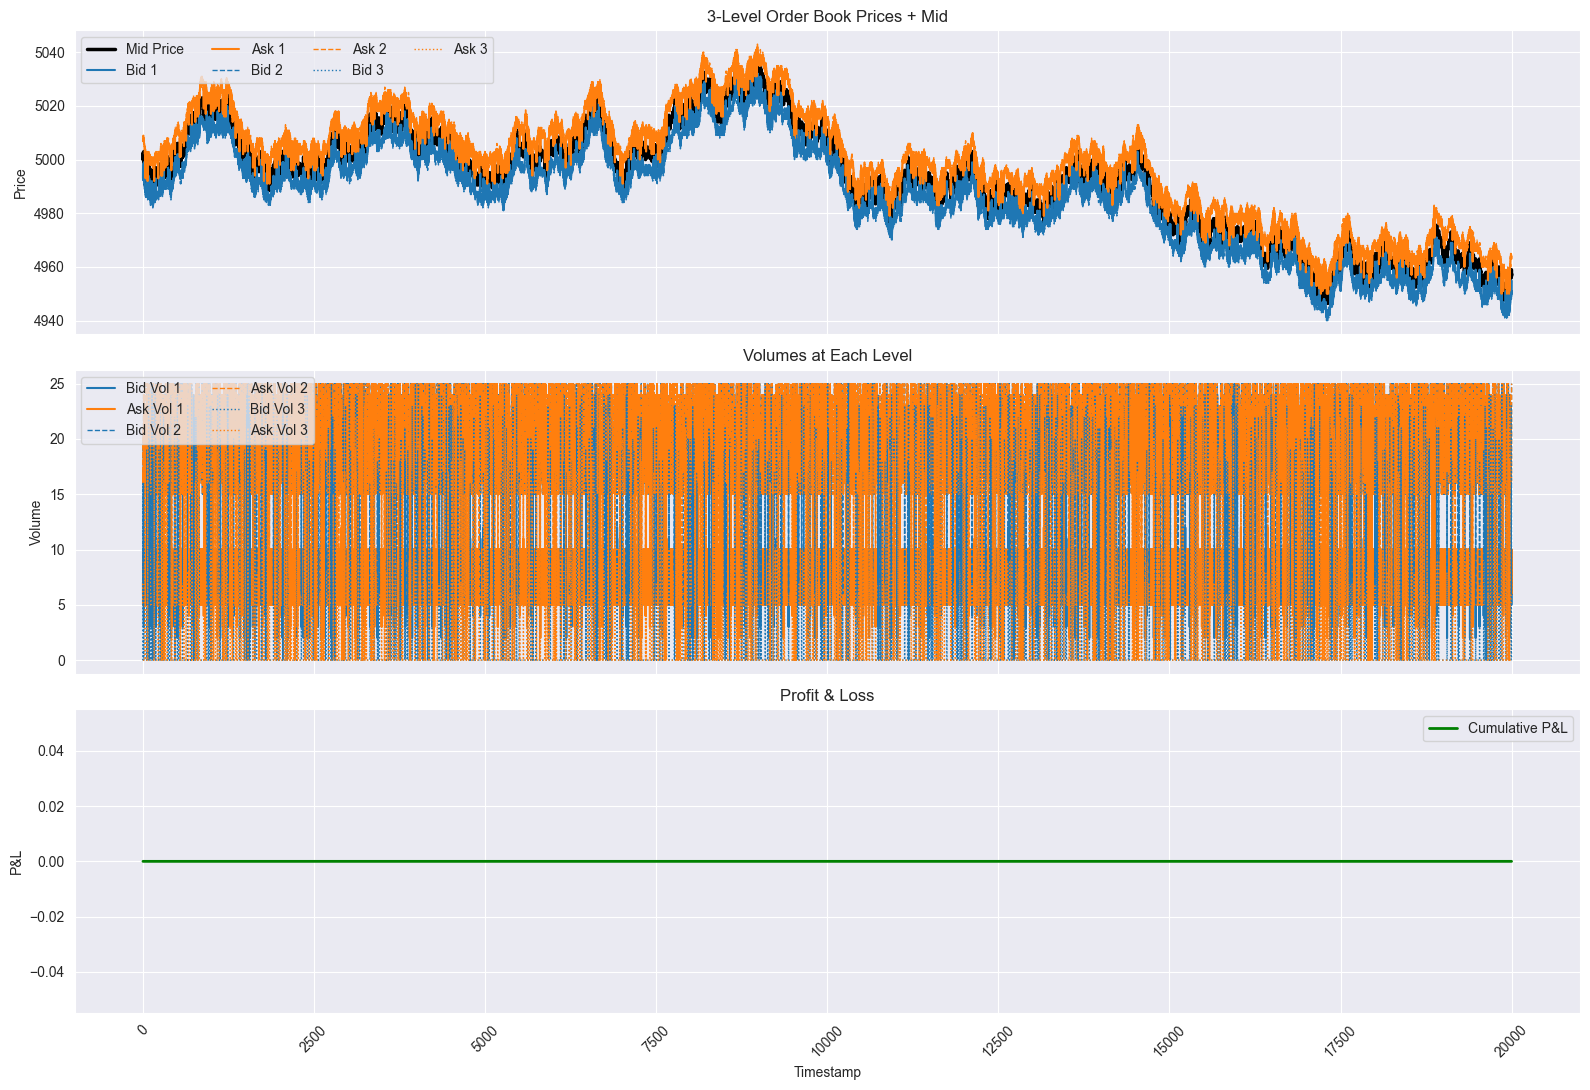

In [396]:
plot_order_depth(
    price_df,
    product="TOMATOES",
)

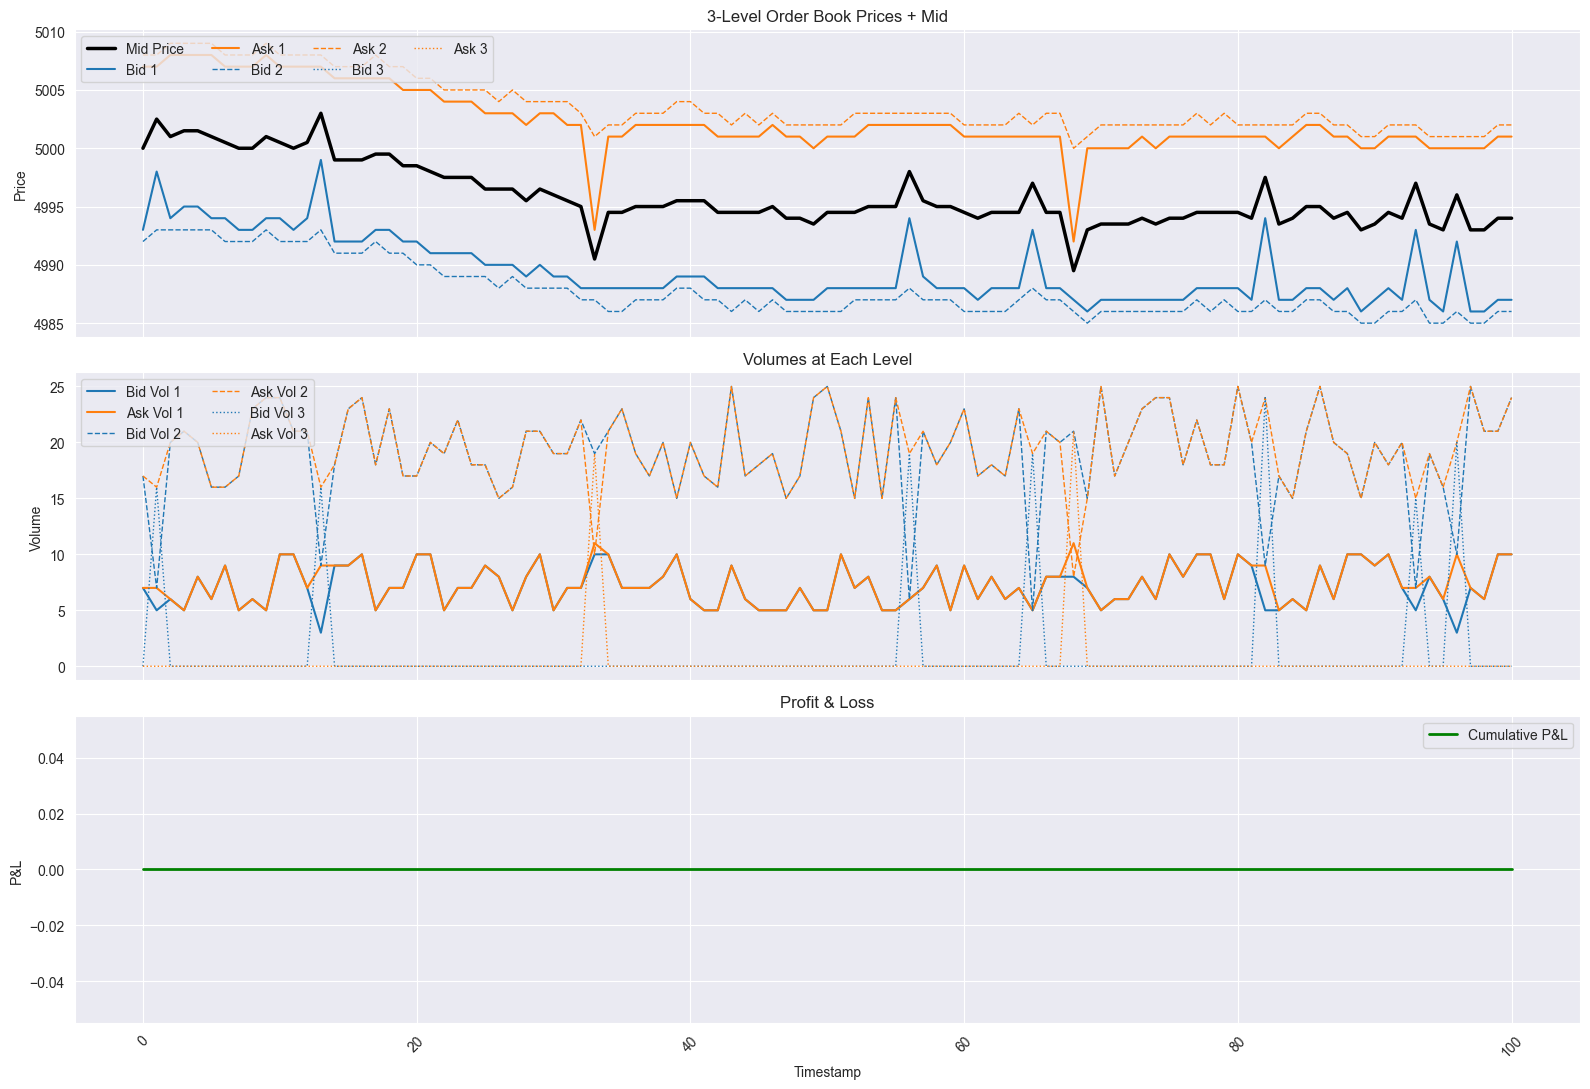

In [14]:
plot_order_depth(
    price_df,
    product="TOMATOES",
    day=-2,
    start_time=0,
    end_time=100 * 100,
)

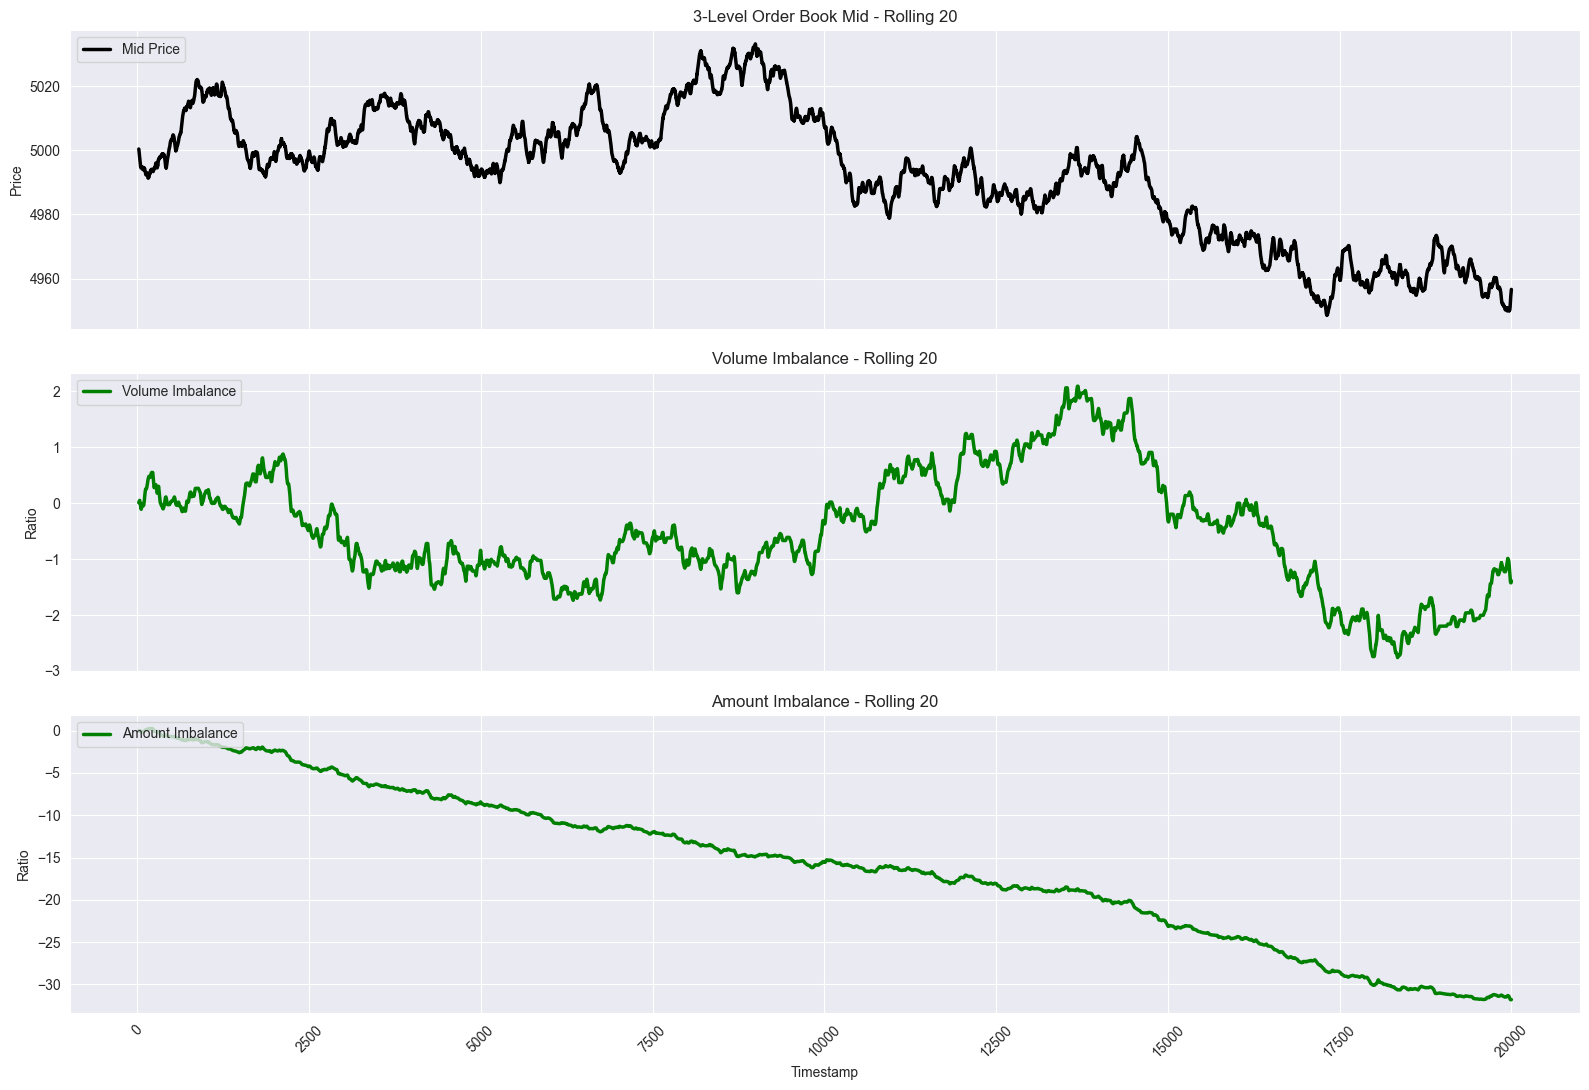

In [15]:
plot_gradual(
    price_df,
    product="TOMATOES",
    window=20,
)

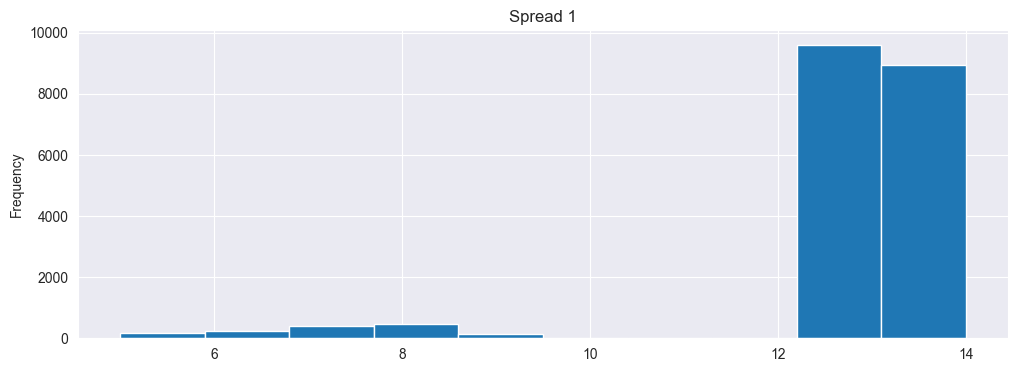

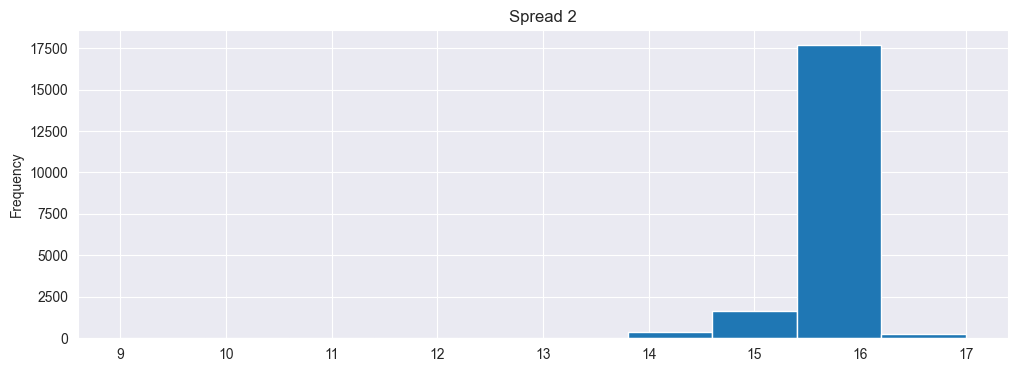

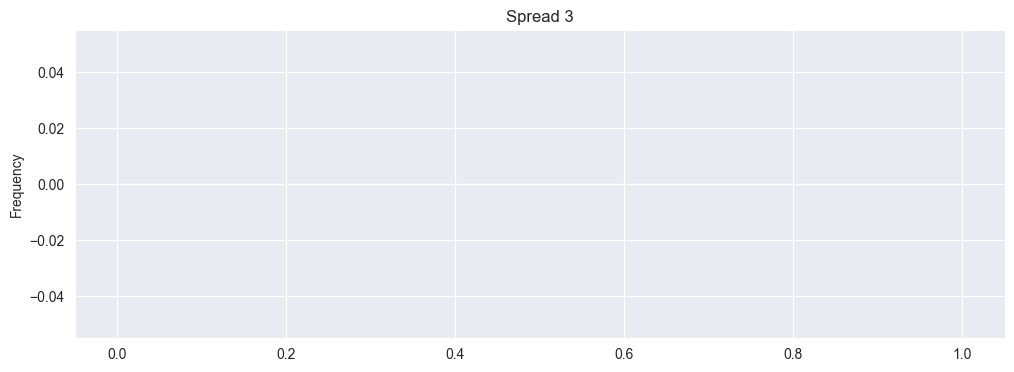

,count
spread_1,
13,9603
14,8954
8,466
7,408
6,253
5,184
9,132


,count
spread_2,
16,17690
15,1666
14,402
17,235
9,5
10,2


,count
spread_3,


In [36]:
plot_spread(price_df, product="TOMATOES")

## EMERALDS

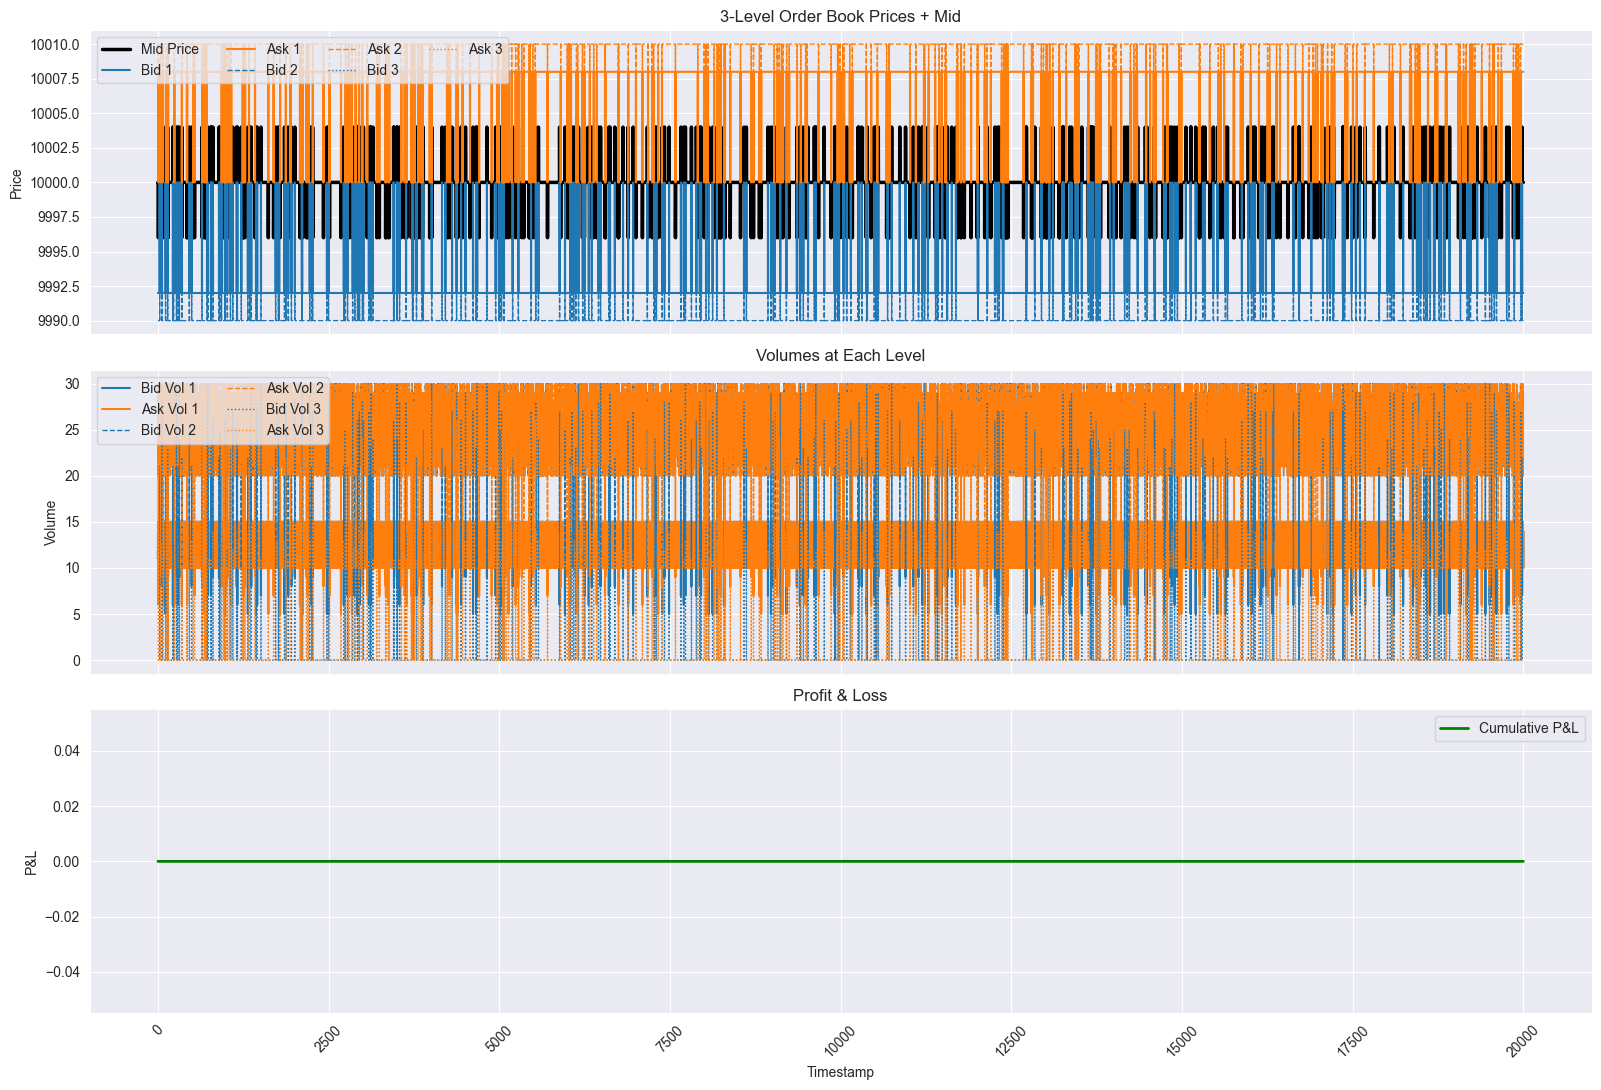

In [17]:
plot_order_depth(
    price_df,
    product="EMERALDS",
)

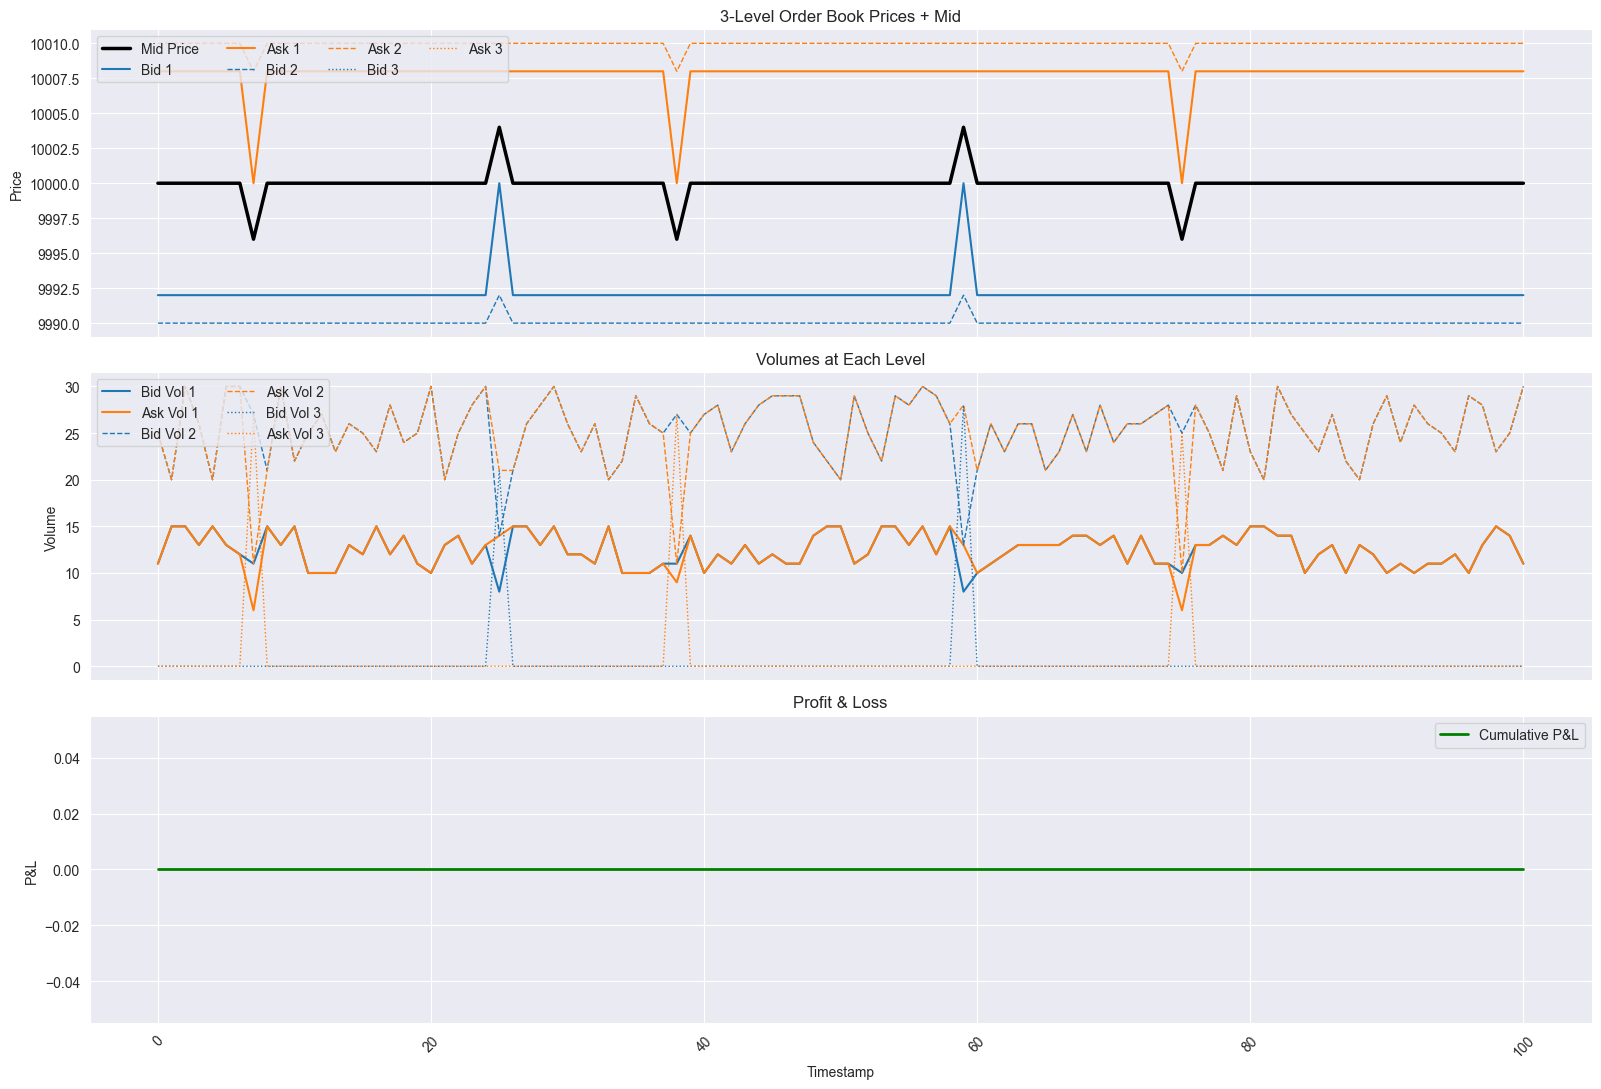

In [18]:
plot_order_depth(
    price_df,
    product="EMERALDS",
    day=-2,
    start_time=0,
    end_time=100 * 100,
)

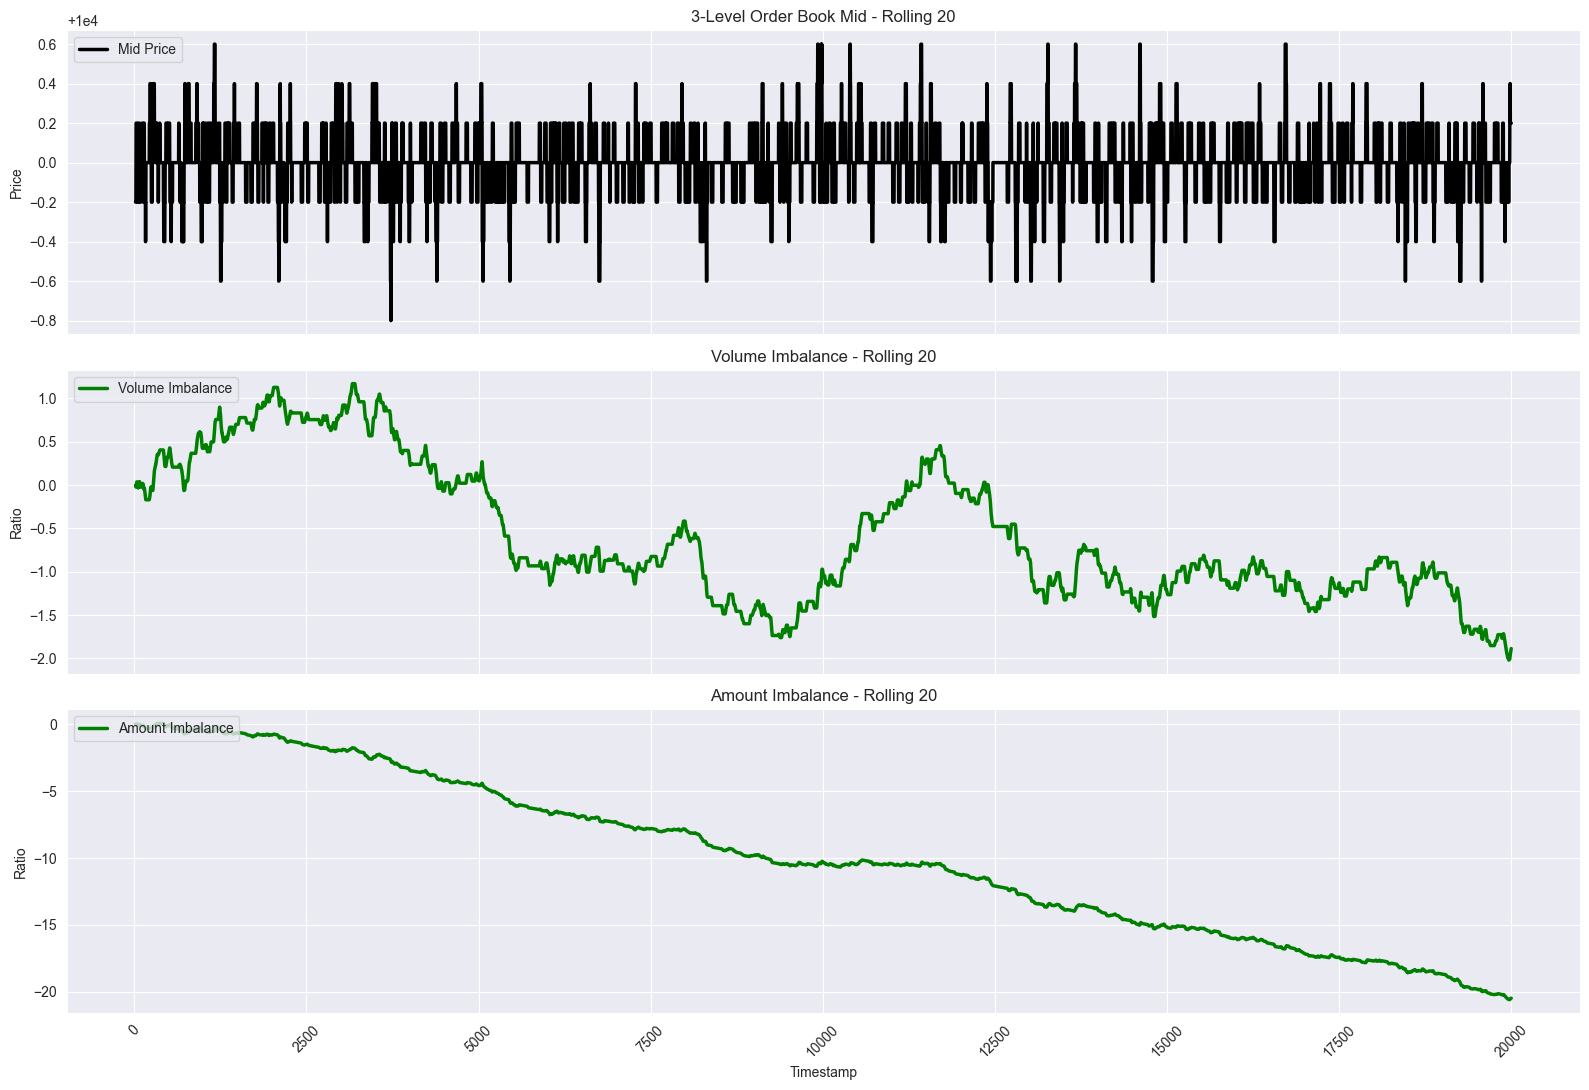

In [19]:
plot_gradual(
    price_df,
    product="EMERALDS",
    window=20,
)

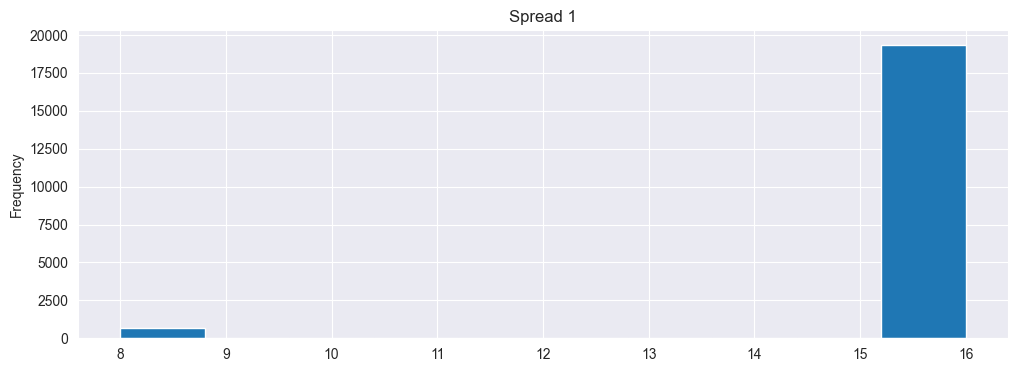

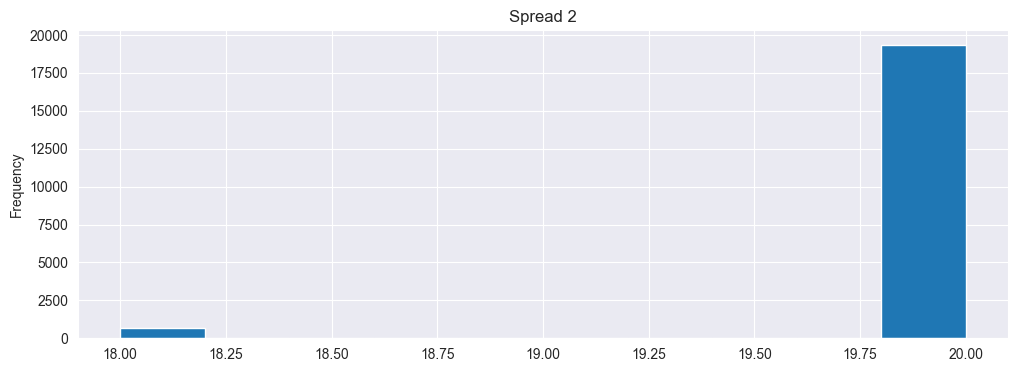

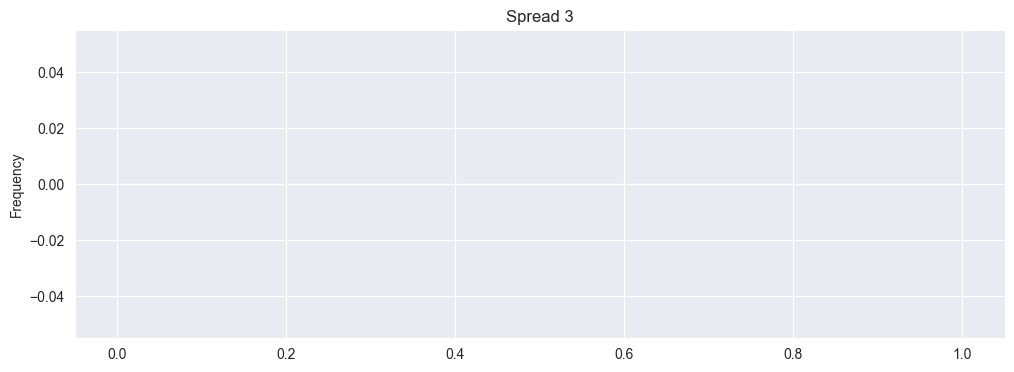

,count
spread_1,
16,19346
8,654


,count
spread_2,
20,19346
18,654


,count
spread_3,


In [37]:
plot_spread(price_df, product="EMERALDS")

# Trades

In [203]:
truncate(
    trade_df,
    "EMERALDS",
)["price"].value_counts()

price
9992.0     199
10008.0    189
10000.0     11
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

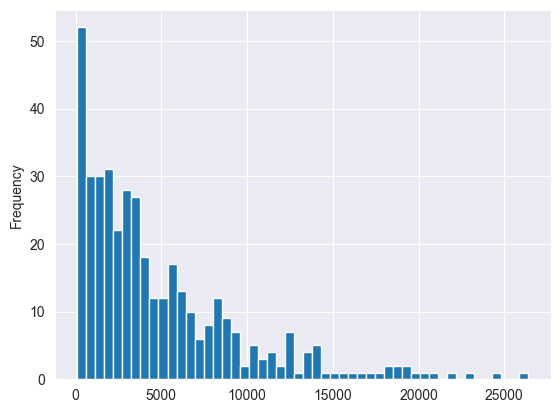

In [338]:
truncate(trade_df, "EMERALDS",).groupby("day")[
    "timestamp"
].diff().plot.hist(bins=50)

In [204]:
truncate_trade(
    trade_df,
    "TOMATOES",
)["price"].value_counts()

price
4991.0    24
4996.0    21
5002.0    20
5008.0    19
5000.0    19
          ..
4956.0     2
5039.0     1
5036.0     1
4943.0     1
4944.0     1
Name: count, Length: 96, dtype: int64

# Dashboard

In [431]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px


# ====================== 3. 主 Dashboard ======================
def create_dashboard(
    df: pd.DataFrame,
    product: str,
    day: int = None,
    start_time: int = None,
    end_time: int = None,
):

    # Truncate data
    df = truncate(df, product, day, start_time, end_time)

    df = df.sort_values(["product", "timestamp"]).reset_index(drop=True)

    # 填充 NaN（trade 相关列在非交易行是空）
    trade_cols = ["buyer", "seller", "currency", "price", "quantity", "trade_direction"]
    for col in trade_cols:
        if col in df.columns:
            df[col] = df[col].fillna("")

    # 提取交易行（用于标记）
    trades = df[df["price"].notna() & (df["price"] != "")].copy()

    if product:
        plot_df = df[df["product"] == product].copy()
        trade_plot = trades[trades["product"] == product].copy()
    else:
        plot_df = df.copy()
        trade_plot = trades.copy()

    fig = make_subplots(
        rows=5,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.04,
        subplot_titles=(
            f"{product or 'All Products'} - Order Book Prices + Trades",
            "Volumes + Volume Imbalance",
            "Spreads (Level 1-3)",
            "Bid/Ask Amount Imbalance",
            "Cumulative P&L + Returns",
        ),
        row_heights=[0.35, 0.15, 0.15, 0.15, 0.20],
    )

    # ==================== Row 1: 价格 + Mid + Trades ====================
    for i, style in zip([1, 2, 3], ["solid", "dash", "dot"]):
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df[f"bid_price_{i}"],
                name=f"Bid {i}",
                line=dict(color="#1f77b4", width=2 if i == 1 else 1, dash=style),
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df[f"ask_price_{i}"],
                name=f"Ask {i}",
                line=dict(color="#ff7f0e", width=2 if i == 1 else 1, dash=style),
            ),
            row=1,
            col=1,
        )

    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["mid_price"],
            name="Mid Price",
            line=dict(color="black", width=3),
        ),
        row=1,
        col=1,
    )

    # 交易标记（超级明显）
    if not trade_plot.empty:
        fig.add_trace(
            go.Scatter(
                x=trade_plot["timestamp"],
                y=trade_plot["price"],
                mode="markers",
                name="Trades",
                marker=dict(
                    size=trade_plot["quantity"] * 2 + 5,  # 大小随 quantity
                    color=trade_plot["trade_direction"].map(
                        {"buy": "#2ca02c", "sell": "#d62728"}
                    ),
                    symbol="triangle-up"
                    if trade_plot["trade_direction"].iloc[0] == "buy"
                    else "triangle-down",
                    line=dict(width=1, color="white"),
                ),
                text=trade_plot.apply(
                    lambda row: f"Buyer: {row['buyer']}<br>Seller: {row['seller']}<br>Qty: {row['quantity']}<br>Dir: {row['trade_direction']}",
                    axis=1,
                ),
                hovertemplate="%{text}<br>Price: %{y}<extra></extra>",
            ),
            row=1,
            col=1,
        )

    # ==================== Row 2: 成交量 + Imbalance ====================
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["bid_volume"],
            name="Bid Vol Total",
            line=dict(color="#1f77b4"),
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["ask_volume"],
            name="Ask Vol Total",
            line=dict(color="#ff7f0e"),
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["volume_imbalance"],
            name="Volume Imbalance",
            line=dict(color="purple", dash="dash"),
        ),
        row=2,
        col=1,
    )

    # ==================== Row 3: Spreads ====================
    for i in [1, 2, 3]:
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df[f"spread_{i}"],
                name=f"Spread Level {i}",
            ),
            row=3,
            col=1,
        )

    # ==================== Row 4: Amount Imbalance ====================
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["amount_imbalance"],
            name="Amount Imbalance",
            line=dict(color="teal"),
        ),
        row=4,
        col=1,
    )

    # ==================== Row 5: PNL + Returns ====================
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["profit_and_loss"],
            name="Cumulative P&L",
            line=dict(color="green", width=3),
        ),
        row=5,
        col=1,
    )
    if "returns_5t" in plot_df.columns:
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df["returns_5t"],
                name="5-tick Returns",
                line=dict(color="orange", dash="dot"),
            ),
            row=5,
            col=1,
        )

    # 美化布局
    fig.update_layout(
        height=1100,
        title_text="🚀 IMC Prosperity 2026 - 高级 Order Book + Trade Dashboard",
        template="plotly_dark",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        xaxis_rangeslider_visible=True,
    )

    fig.update_xaxes(title_text="Timestamp", row=5, col=1)
    fig.show()

    # 保存为独立 HTML（发给队友超方便）
    fig.write_html(f"prosperity_dashboard_{product or 'all'}.html")
    print(f"✅ Dashboard 已保存为 prosperity_dashboard_{product or 'all'}.html")

In [433]:
agg_df['price']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
39996   NaN
39997   NaN
39998   NaN
39999   NaN
40000   NaN
Name: price, Length: 40001, dtype: float64

In [432]:
create_dashboard(
    agg_df,
    'TOMATOES',
)

ValueError: 
    Invalid value of type 'pandas.Series' received for the 'size' property of scatter.marker
        Received value: 18        9.0
34       11.0
69        9.0
82       11.0
134      15.0
         ... 
19787     9.0
19831     9.0
19835    13.0
19862     9.0
19914    11.0
Name: quantity, Length: 820, dtype: object

    The 'size' property is a number and may be specified as:
      - An int or float in the interval [0, inf]
      - A tuple, list, or one-dimensional numpy array of the above

In [ ]:
import plotly.express as px
from plotly.subplots import make_subplots

# ====================== 1. 加载你的 DataFrame ======================
# df = your_updated_dataframe   # 替换成你的 df
# 假设 df 已经加载好

# ====================== 2. 预处理 ======================
df = df.sort_values(["product", "timestamp"]).reset_index(drop=True)

# 填充 NaN（trade 相关列在非交易行是空）
trade_cols = ["buyer", "seller", "currency", "price", "quantity", "trade_direction"]
for col in trade_cols:
    if col in df.columns:
        df[col] = df[col].fillna("")

# 提取交易行（用于标记）
trades = df[df["price"].notna() & (df["price"] != "")].copy()

# ====================== 3. 主 Dashboard ======================
def create_dashboard(df: pd.DataFrame, product: str = None):
    if product:
        plot_df = df[df["product"] == product].copy()
        trade_plot = trades[trades["product"] == product].copy()
    else:
        plot_df = df.copy()
        trade_plot = trades.copy()

    fig = make_subplots(
        rows=5,
        cols=1,
        shared_xaxes=True,
        vertical_spacing=0.04,
        subplot_titles=(
            f"{product or 'All Products'} - Order Book Prices + Trades",
            "Volumes + Volume Imbalance",
            "Spreads (Level 1-3)",
            "Bid/Ask Amount Imbalance",
            "Cumulative P&L + Returns",
        ),
        row_heights=[0.35, 0.15, 0.15, 0.15, 0.20],
    )

    # ==================== Row 1: 价格 + Mid + Trades ====================
    for i, style in zip([1, 2, 3], ["solid", "dash", "dot"]):
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df[f"bid_price_{i}"],
                name=f"Bid {i}",
                line=dict(color="#1f77b4", width=2 if i == 1 else 1, dash=style),
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df[f"ask_price_{i}"],
                name=f"Ask {i}",
                line=dict(color="#ff7f0e", width=2 if i == 1 else 1, dash=style),
            ),
            row=1,
            col=1,
        )

    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["mid_price"],
            name="Mid Price",
            line=dict(color="black", width=3),
        ),
        row=1,
        col=1,
    )

    # 交易标记（超级明显）
    if not trade_plot.empty:
        fig.add_trace(
            go.Scatter(
                x=trade_plot["timestamp"],
                y=trade_plot["price"],
                mode="markers",
                name="Trades",
                marker=dict(
                    size=trade_plot["quantity"] * 2 + 5,  # 大小随 quantity
                    color=trade_plot["trade_direction"].map(
                        {"buy": "#2ca02c", "sell": "#d62728"}
                    ),
                    symbol="triangle-up"
                    if trade_plot["trade_direction"].iloc[0] == "buy"
                    else "triangle-down",
                    line=dict(width=1, color="white"),
                ),
                text=trade_plot.apply(
                    lambda row: f"Buyer: {row['buyer']}<br>Seller: {row['seller']}<br>Qty: {row['quantity']}<br>Dir: {row['trade_direction']}",
                    axis=1,
                ),
                hovertemplate="%{text}<br>Price: %{y}<extra></extra>",
            ),
            row=1,
            col=1,
        )

    # ==================== Row 2: 成交量 + Imbalance ====================
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["bid_volume"],
            name="Bid Vol Total",
            line=dict(color="#1f77b4"),
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["ask_volume"],
            name="Ask Vol Total",
            line=dict(color="#ff7f0e"),
        ),
        row=2,
        col=1,
    )
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["volume_imbalance"],
            name="Volume Imbalance",
            line=dict(color="purple", dash="dash"),
        ),
        row=2,
        col=1,
    )

    # ==================== Row 3: Spreads ====================
    for i in [1, 2, 3]:
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df[f"spread_{i}"],
                name=f"Spread Level {i}",
            ),
            row=3,
            col=1,
        )

    # ==================== Row 4: Amount Imbalance ====================
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["amount_imbalance"],
            name="Amount Imbalance",
            line=dict(color="teal"),
        ),
        row=4,
        col=1,
    )

    # ==================== Row 5: PNL + Returns ====================
    fig.add_trace(
        go.Scatter(
            x=plot_df["timestamp"],
            y=plot_df["profit_and_loss"],
            name="Cumulative P&L",
            line=dict(color="green", width=3),
        ),
        row=5,
        col=1,
    )
    if "returns_5t" in plot_df.columns:
        fig.add_trace(
            go.Scatter(
                x=plot_df["timestamp"],
                y=plot_df["returns_5t"],
                name="5-tick Returns",
                line=dict(color="orange", dash="dot"),
            ),
            row=5,
            col=1,
        )

    # 美化布局
    fig.update_layout(
        height=1100,
        title_text="🚀 IMC Prosperity 2026 - 高级 Order Book + Trade Dashboard",
        template="plotly_dark",
        hovermode="x unified",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
        xaxis_rangeslider_visible=True,
    )

    fig.update_xaxes(title_text="Timestamp", row=5, col=1)
    fig.show()

    # 保存为独立 HTML（发给队友超方便）
    fig.write_html(f"prosperity_dashboard_{product or 'all'}.html")
    print(f"✅ Dashboard 已保存为 prosperity_dashboard_{product or 'all'}.html")


# ====================== 运行示例 ======================
# 单产品
create_dashboard(df, product="TOMATOES")
create_dashboard(df, product="EMERALDS")

# 或者看全部
# create_dashboard(df)

# Prediction
* To aggregate price & trades together.
* The trade flow might have predictive power,
* given the fact that informed traders need to execute the trades,
* to realise their insights and make profit.

In [398]:
agg_df["label_1t"] = (
    agg_df.groupby("product")["mid_price"].shift(-1) / agg_df["mid_price"] - 1
)
agg_df["label_5t"] = (
    agg_df.groupby("product")["mid_price"].shift(-5) / agg_df["mid_price"] - 1
)

## price pct change

label_1t,returns
product,
EMERALDS,-0.485190
TOMATOES,-0.213606


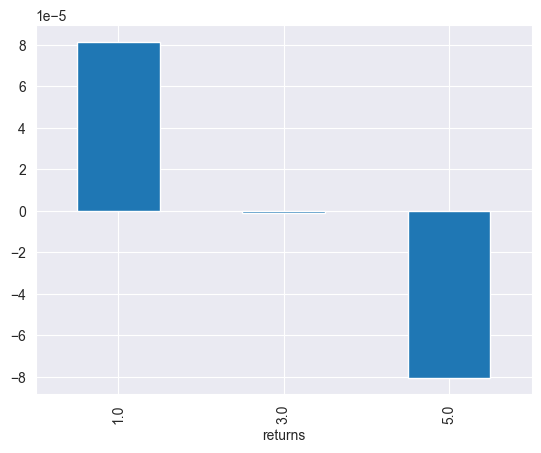

product
EMERALDS   -0.487563
TOMATOES   -0.419745
dtype: float64

In [387]:
x_col = "returns"
y_col = "label_1t"

sub_df = agg_df.dropna(subset=[x_col, y_col])

# Corr
display(
    sub_df.groupby("product").apply(
        lambda x: x[[x_col, y_col]].corr(method="spearman").iloc[:-1, -1]
    )
)

# y by group
g = np.ceil(sub_df[x_col].rank(pct=True).mul(5))
y8g = agg_df[y_col].groupby(g).mean()
y8g.plot.bar()
plt.show()

# Beta
coef = sub_df.groupby("product").apply(
    lambda x: np.cov(x[x_col], x[y_col])[0, 1] / np.var(x[x_col])
)
display(coef)

## price spread

label_1t,spread_1_1
product,
EMERALDS,-0.024850
TOMATOES,-0.012183


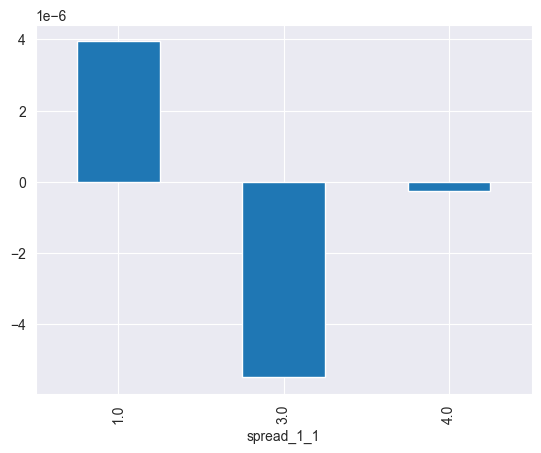

product
EMERALDS   -9.681285e-07
TOMATOES   -1.336708e-05
dtype: float64

In [399]:
x_col = "spread_1_1"
y_col = "label_1t"

sub_df = agg_df.dropna(subset=[x_col, y_col])

# Corr
display(
    sub_df.groupby("product").apply(
        lambda x: x[[x_col, y_col]].corr(method="spearman").iloc[:-1, -1]
    )
)

# y by group
g = np.ceil(sub_df[x_col].rank(pct=True).mul(5))
y8g = agg_df[y_col].groupby(g).mean()
y8g.plot.bar()
plt.show()

# Beta
coef = sub_df.groupby("product").apply(
    lambda x: np.cov(x[x_col], x[y_col])[0, 1] / np.var(x[x_col])
)
display(coef)

## volume imbalance

label_1t,volume_imbalance
product,
EMERALDS,-0.699000
TOMATOES,-0.416484


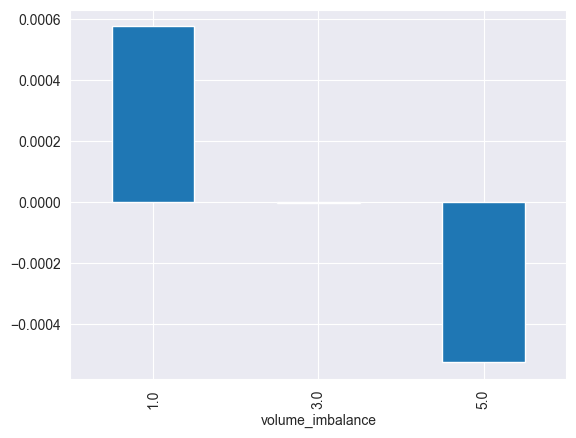

product
EMERALDS   -0.004057
TOMATOES   -0.005811
dtype: float64

In [385]:
x_col = "volume_imbalance"
y_col = "label_1t"

sub_df = agg_df.dropna(subset=[x_col, y_col])

# Corr
display(
    sub_df.groupby("product").apply(
        lambda x: x[[x_col, y_col]].corr(method="spearman").iloc[:-1, -1]
    )
)

# y by group
g = np.ceil(sub_df[x_col].rank(pct=True).mul(5))
y8g = agg_df[y_col].groupby(g).mean()
y8g.plot.bar()
plt.show()

# Beta
coef = sub_df.groupby("product").apply(
    lambda x: np.cov(x[x_col], x[y_col])[0, 1] / np.var(x[x_col])
)
display(coef)

label_1t,volume_imbalance
product,
EMERALDS,-0.852435
TOMATOES,-0.831240


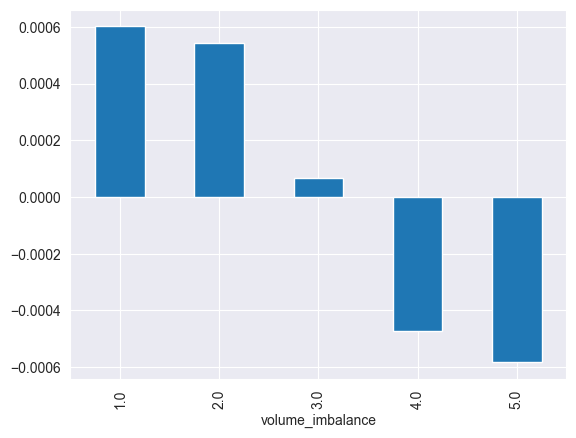

product
EMERALDS   -0.004064
TOMATOES   -0.005812
dtype: float64

In [386]:
x_col = "volume_imbalance"
y_col = "label_1t"

sub_df = agg_df.dropna(subset=[x_col, y_col]).query(f"{x_col} != 0")

# Corr
display(
    sub_df.groupby("product").apply(
        lambda x: x[[x_col, y_col]].corr(method="spearman").iloc[:-1, -1]
    )
)

# y by group
g = np.ceil(sub_df[x_col].rank(pct=True).mul(5))
y8g = agg_df[y_col].groupby(g).mean()
y8g.plot.bar()
plt.show()

# Beta
coef = sub_df.groupby("product").apply(
    lambda x: np.cov(x[x_col], x[y_col])[0, 1] / np.var(x[x_col])
)
display(coef)

## amount imbalance

label_1t,amount_imbalance
product,
EMERALDS,-0.218166
TOMATOES,-0.188630


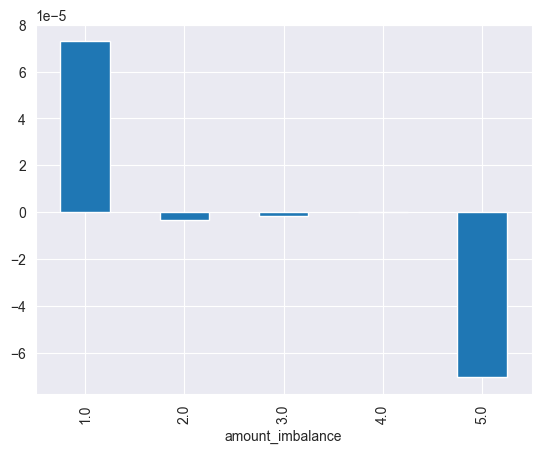

product
EMERALDS   -0.004057
TOMATOES   -0.005812
dtype: float64

In [388]:
x_col = "amount_imbalance"
y_col = "label_1t"

sub_df = agg_df.dropna(subset=[x_col, y_col])

# Corr
display(
    sub_df.groupby("product").apply(
        lambda x: x[[x_col, y_col]].corr(method="spearman").iloc[:-1, -1]
    )
)

# y by group
g = np.ceil(sub_df[x_col].rank(pct=True).mul(5))
y8g = agg_df[y_col].groupby(g).mean()
y8g.plot.bar()
plt.show()

# Beta
coef = sub_df.groupby("product").apply(
    lambda x: np.cov(x[x_col], x[y_col])[0, 1] / np.var(x[x_col])
)
display(coef)

## trade direction

In [303]:
agg_df.dropna(subset="price").groupby("product").apply(
    lambda x: x[["trade_direction", "label_5t"]].corr().iloc[0, 1]
)

product
EMERALDS    0.043784
TOMATOES    0.010965
dtype: float64

In [310]:
x = truncate(agg_df, "TOMATOES")["volume_imbalance"]
y = truncate(agg_df, "TOMATOES")["label_1t"]

In [314]:
x.value_counts()

volume_imbalance
 0.000000    18557
-0.090909       30
 0.090909       24
-0.076923       22
 0.047619       16
             ...  
-0.150000        1
-0.121212        1
 0.206897        1
 0.045455        1
 0.192308        1
Name: count, Length: 266, dtype: int64

<Axes: ylabel='Frequency'>

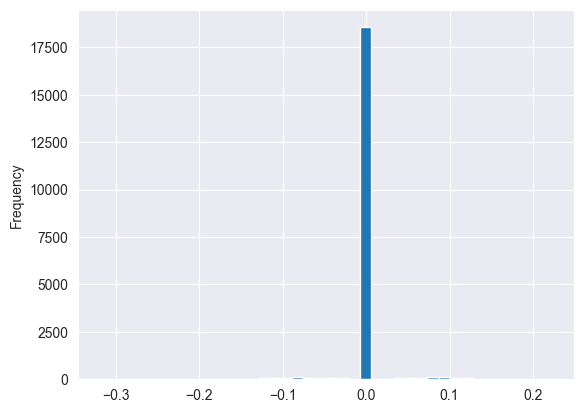

In [322]:
x.plot.hist(bins=40)

<Axes: ylabel='Frequency'>

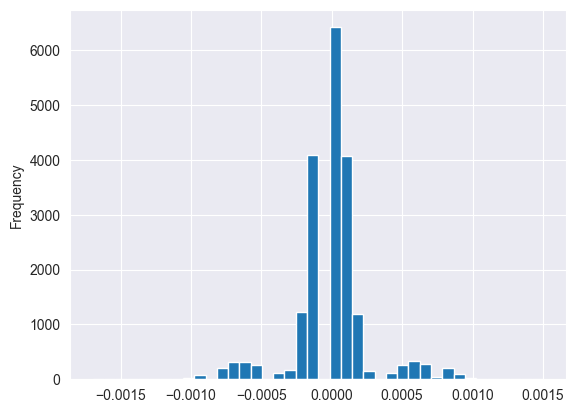

In [320]:
y.plot.hist(bins=40)

'label_1t'

# Log

In [415]:
import re
from typing import Any, Dict


def parse_lambda_log(log_str: str) -> Dict[str, Any]:
    if not log_str:
        return {}

    # Extract all "Acceptable price : XXX"
    prices = re.findall(r"Acceptable price :\s*([\d.]+)", log_str)
    em_price = float(prices[0]) if len(prices) > 0 else None
    tom_price = float(prices[1]) if len(prices) > 1 else None

    # Extract all "Buy Order depth : X, Sell order depth : Y"
    depths = re.findall(
        r"Buy Order depth :\s*(\d+),\s*Sell order depth :\s*(\d+)", log_str
    )
    em_buy, em_sell = map(int, depths[0]) if len(depths) > 0 else (None, None)
    tom_buy, tom_sell = map(int, depths[1]) if len(depths) > 1 else (None, None)

    return {
        "acceptable_emeralds": em_price,
        "acceptable_tomatoes": tom_price,
        "depth_buy_emeralds": em_buy,
        "depth_sell_emeralds": em_sell,
        "depth_buy_tomatoes": tom_buy,
        "depth_sell_tomatoes": tom_sell,
    }


def load_log_file(log_number: int):
    results = {}
    with ZipFile(f"../logs/{log_number}.zip", "r") as z:
        with z.open(f"{log_number}.log") as file:
            log_data = json.load(file)

    results["data"] = log_data
    results["submissionId"] = log_data["submissionId"]
    results["activitiesLog"] = pd.read_csv(StringIO(log_data["activitiesLog"]), sep=";")
    results["tradeHistory"] = pd.DataFrame(log_data["tradeHistory"])

    # logs: complicated
    ls = log_data["logs"]
    a = pd.DataFrame(ls)
    parsed_rows = [parse_lambda_log(row["lambdaLog"]) for row in ls]
    b = pd.DataFrame(parsed_rows)
    df = pd.concat([a[["timestamp"]], b], axis=1)
    df = df.sort_values("timestamp").reset_index(drop=True)
    results["logs"] = df

    return results

In [416]:
results = load_log_file(15534)

# trade
trades = results["tradeHistory"]
if trades.shape[0] > 0:
    trades = trades.rename(columns={"symbol": "product"})
    trades_own = trades.loc[
        (trades["buyer"].apply(len) > 0) | trades["seller"].apply(len) > 0
    ]
    is_buy = trades_own["buyer"].eq("SUBMISSION")
    is_sell = trades_own["seller"].eq("SUBMISSION")
    trades_own["signed_quantity"] = is_buy.astype(int) * trades_own["quantity"]
    trades_own["signed_quantity"] += -is_sell.astype(int) * trades_own["quantity"]
    trades_own["position"] = trades_own.groupby("product")["signed_quantity"].cumsum()

# price & pnl
pnl = results["activitiesLog"]

# logs
logs = results["logs"]

## Position

In [412]:
trades_own.tail()

,timestamp,buyer,seller,product,currency,price,quantity,signed_quantity,position
90,185100,SUBMISSION,,TOMATOES,XIRECS,4983.0,4,4,-50
91,185300,,SUBMISSION,EMERALDS,XIRECS,10007.0,6,-6,-16
96,195500,SUBMISSION,,TOMATOES,XIRECS,4984.0,4,4,-46
97,195900,,SUBMISSION,TOMATOES,XIRECS,4997.0,2,-2,-48
98,198500,,SUBMISSION,TOMATOES,XIRECS,5001.0,5,-5,-53


<Axes: xlabel='timestamp'>

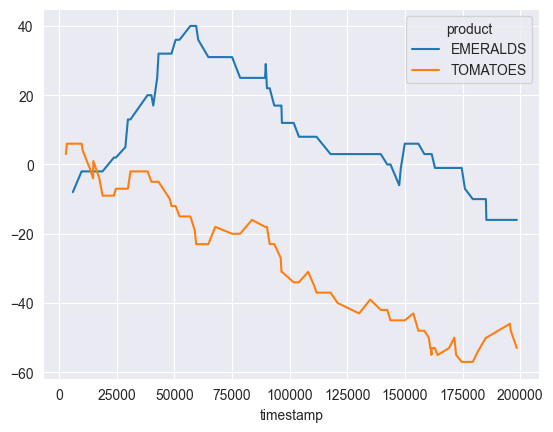

In [278]:
position = trades_own.pivot_table(
    index="timestamp", columns="product", values="position"
).ffill()
position.plot()

## PNL

product,EMERALDS,TOMATOES
timestamp,,
199500,1050.0,676.78125
199600,1050.0,682.28125
199700,1050.0,644.87500
199800,1050.0,663.46875
199900,1050.0,593.65625


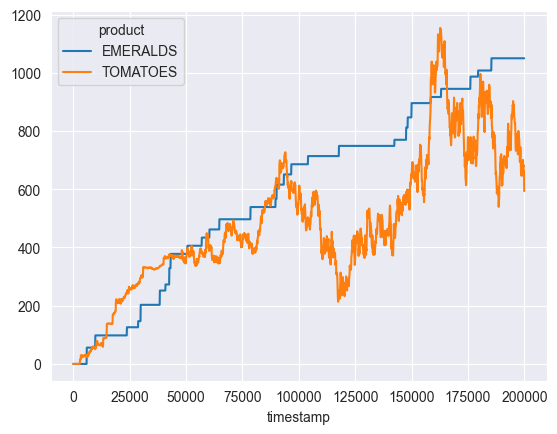

In [252]:
pnl8p = pnl.pivot_table(values="profit_and_loss", index="timestamp", columns="product")
pnl8p.plot()
display(pnl8p.tail())

## Errors

In [414]:
results["data"]["logs"][0]["sandboxLog"]

'[ERROR] ZeroDivisionError: division by zero\\n{"errorMessage": "division by zero", "errorType": "ZeroDivisionError", "requestId": "2f9d0a4d-dc25-44c7-91d4-bc747af607da", "stackTrace": ["  File \\"/var/task/app.py\\", line 30, in lambda_handler\\n    orders, conversion, traderData = trader.run(trading_state)\\n", "  File \\"/var/task/trader.py\\", line 134, in run\\n    fair_price = self._get_fair_price(product, state)\\n", "  File \\"/var/task/trader.py\\", line 43, in _get_fair_price\\n    volume_imbalance = ask_volume - bid_volume / (ask_volume + bid_volume)\\n"]}'

In [225]:
results["data"]["logs"][0:2]

[{'sandboxLog': '',
  'lambdaLog': 'traderData: \nObservations: (plainValueObservations: {}, conversionObservations: {})\nBuy Order depth : 2, Sell order depth : 2\nAcceptable price : 10000\nPassive BUY 40x 9992\nPassive SELL -40x 10008\nPassive BUY 40x 9994\nPassive SELL -40x 10006\nBuy Order depth : 2, Sell order depth : 2\nAcceptable price : 5006.0\nPassive BUY 80x 5000\nPassive SELL -80x 5012',
  'timestamp': 0},
 {'sandboxLog': '',
  'lambdaLog': 'traderData: SAMPLE\nObservations: (plainValueObservations: {}, conversionObservations: {})\nBuy Order depth : 2, Sell order depth : 2\nAcceptable price : 10000\nPassive BUY 40x 9992\nPassive SELL -40x 10008\nPassive BUY 40x 9994\nPassive SELL -40x 10006\nBuy Order depth : 2, Sell order depth : 2\nAcceptable price : 5006.5\nPassive BUY 80x 5000\nPassive SELL -80x 5012',
  'timestamp': 100}]

In [227]:
trades.query('symbol == "EMERALDS"').sort_values("timestamp")

,timestamp,buyer,seller,symbol,currency,price,quantity
2,5900,,SUBMISSION,EMERALDS,XIRECS,10006.0,8
3,9700,SUBMISSION,,EMERALDS,XIRECS,9994.0,6
10,23700,SUBMISSION,,EMERALDS,XIRECS,9994.0,4
13,28700,SUBMISSION,,EMERALDS,XIRECS,9994.0,3
14,29800,SUBMISSION,,EMERALDS,XIRECS,9994.0,8
16,38300,SUBMISSION,,EMERALDS,XIRECS,9994.0,7
18,40800,,SUBMISSION,EMERALDS,XIRECS,10006.0,3
19,42500,SUBMISSION,,EMERALDS,XIRECS,9994.0,8
20,43100,SUBMISSION,,EMERALDS,XIRECS,9994.0,7
24,50500,SUBMISSION,,EMERALDS,XIRECS,9994.0,4


In [234]:
trades

,timestamp,buyer,seller,symbol,currency,price,quantity
0,2900,SUBMISSION,,TOMATOES,XIRECS,4998.0,3
1,3300,SUBMISSION,,TOMATOES,XIRECS,4997.0,3
2,5900,,SUBMISSION,EMERALDS,XIRECS,10006.0,8
3,9700,SUBMISSION,,EMERALDS,XIRECS,9994.0,6
4,10200,,SUBMISSION,TOMATOES,XIRECS,5014.0,2
...,...,...,...,...,...,...,...
94,193000,,,TOMATOES,XIRECS,4984.0,5
95,193900,,,TOMATOES,XIRECS,4985.0,3
96,195500,SUBMISSION,,TOMATOES,XIRECS,4984.0,4
97,195900,,SUBMISSION,TOMATOES,XIRECS,4997.0,2


In [233]:
trades.query('symbol == "TOMATOES"').sort_values("timestamp")["quantity"].value_counts()

quantity
2    21
5    18
3    16
4    15
Name: count, dtype: int64